<a href="https://colab.research.google.com/github/MuhammadIeyan/Canvas-Connect/blob/main/UIUC_Airfoil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.0 MB/s eta 0:00:00


In [3]:
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

In [5]:
st.set_page_config(page_title="Airfoil Noise Predictor", layout="wide")

st.write("""
# Airfoil Self-Noise Predictor
Prediction of the **Sound Pressure Level (dB)** generated by an airfoil using the **NASA/UCI Machine Learning dataset**.
""")

@st.cache_resource
def build_model():
    # Load Data
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat"
    columns = ["Frequency", "Angle_of_Attack", "Chord_Length", "Velocity", "Thickness", "Decibels"]
    df = pd.read_csv(url, sep='\t', names=columns)

    # Preprocessing
    X = df.drop("Decibels", axis=1)
    y = df["Decibels"]

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Defining the XGB Model
    model = XGBRegressor(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=6,
        objective='reg:squarederror',
        random_state=42
    )
    model.fit(X_scaled, y)

    return model, scaler, df

model, scaler, df = build_model()

2025-12-06 22:05:01.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:01.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:01.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:01.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [6]:
st.sidebar.header("User Input Parameters")

def user_input_features():
    freq = st.sidebar.slider("Frequency (Hz)",
                             int(df.Frequency.min()),
                             int(df.Frequency.max()),
                             int(df.Frequency.mean()))

    angle = st.sidebar.slider("Angle of Attack (°)",
                              float(df.Angle_of_Attack.min()),
                              float(df.Angle_of_Attack.max()),
                              float(df.Angle_of_Attack.mean()))

    chord = st.sidebar.slider("Chord Length (m)",
                              float(df.Chord_Length.min()),
                              float(df.Chord_Length.max()),
                              float(df.Chord_Length.mean()))

    velocity = st.sidebar.slider("Free-stream Velocity (m/s)",
                                 float(df.Velocity.min()),
                                 float(df.Velocity.max()),
                                 float(df.Velocity.mean()))

    thickness = st.sidebar.slider("Displacement Thickness (m)",
                                  float(df.Thickness.min()),
                                  float(df.Thickness.max()),
                                  float(df.Thickness.mean()), format="%.4f")

    data = {
        'Frequency': freq,
        'Angle_of_Attack': angle,
        'Chord_Length': chord,
        'Velocity': velocity,
        'Thickness': thickness
    }
    return pd.DataFrame(data, index=[0])

input_df = user_input_features()

2025-12-06 22:05:09.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:09.431 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:09.434 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:09.441 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:09.442 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:09.444 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:09.447 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:09.451 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [7]:
st.subheader("Current Parameters")
st.write(input_df)

input_scaled = scaler.transform(input_df)
prediction = model.predict(input_scaled)

st.subheader("Predicted Noise Level")
st.metric(label="Sound Pressure Level", value=f"{prediction[0]:.2f} dB")

2025-12-06 22:05:22.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:22.066 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:22.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:22.197 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:22.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:22.202 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:22.258 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:22.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

2025-12-06 22:05:25.838 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:25.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:25.845 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:25.849 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:25.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:25.858 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:26.270 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-06 22:05:27.313 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

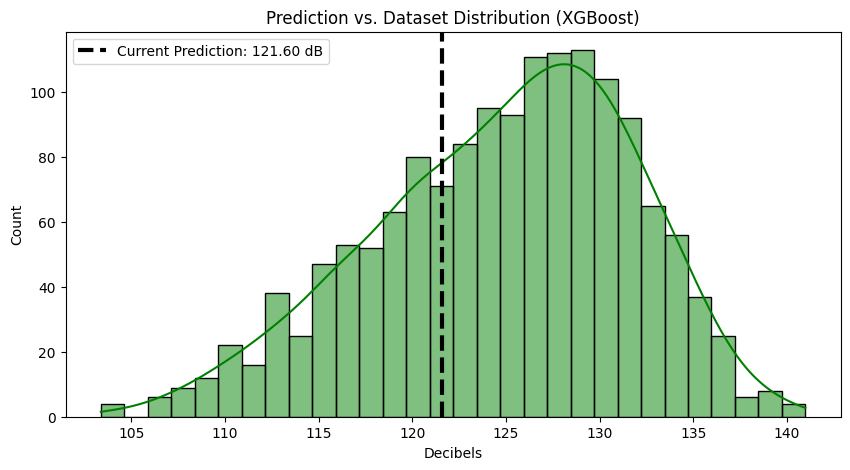

In [8]:
st.write("---")
st.header("Visual Context")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Decibels'], bins=30, kde=True, color="green", ax=ax)  # Changed color to distinguish from RF
ax.axvline(prediction[0], color='black', linestyle='--', linewidth=3, label=f'Current Prediction: {prediction[0]:.2f} dB')
ax.set_title("Prediction vs. Dataset Distribution (XGBoost)")
ax.legend()
st.pyplot(fig)

In [9]:
!git init

Reinitialized existing Git repository in /content/.git/


In [10]:
!git add.

git: 'add.' is not a git command. See 'git --help'.

The most similar command is
	add
